In [1]:
!pip install prophet

In [4]:
!unzip dataset_d3_filtrado.zip

Archive:  dataset_d3_filtrado.zip
  inflating: dataset_d3_filtrado.csv  


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import joblib
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error
from prophet.diagnostics import cross_validation, performance_metrics

# Cargar dataset
df = pd.read_csv("dataset_d3_filtrado.csv")
df['datetime'] = pd.to_datetime(df['datetime'])

# Preprocesamiento
df = df[df['num_placas'] > 0]
df['produccion_por_placa'] = df['produccion_kWh'] / df['num_placas']
df.sort_values(by='datetime', inplace=True)

# Reemplazar NaN en 'nubosidad' con 0 antes de agrupar
df['nubosidad'] = df['nubosidad'].fillna(0)

# Calcular producción del día anterior
df['produccion_dia_anterior'] = df.groupby('id_casa')['produccion_por_placa'].shift(24)
df['produccion_dia_anterior'] = df['produccion_dia_anterior'].fillna(0)

# Agrupar por casa y hora
df_grouped = df.groupby(['id_casa', 'datetime', 'nubosidad', 'festivo', 'produccion_dia_anterior'], as_index=False).agg({'produccion_por_placa': 'mean'})

# Reemplazar NaN en 'nubosidad' después de agrupar
df_grouped['nubosidad'] = df_grouped['nubosidad'].fillna(0)

# Entrenar y guardar modelos
os.makedirs("modelos_prophet", exist_ok=True)
resultados_por_casa = {}

# Iterar sobre cada casa
for casa_id in df_grouped['id_casa'].unique():
    df_casa = df_grouped[df_grouped['id_casa'] == casa_id]

    df_prophet = df_casa.rename(columns={'datetime': 'ds', 'produccion_por_placa': 'y', 'festivo': 'holiday'})

    # Crear dataframe de festivos
    festivos = df_prophet[df_prophet['holiday'] == 1][['ds', 'holiday']].rename(columns={'holiday': 'holiday'})
    festivos['holiday'] = 'festivo'  # Asignar un nombre al evento festivo

    modelo = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True,
        seasonality_mode='additive',
        changepoint_prior_scale=0.1,
        seasonality_prior_scale=10,
        interval_width=0.90,
        holidays=festivos  # Añadir festivos
    )

    # Añadir regresores adicionales
    modelo.add_regressor('nubosidad')
    modelo.add_regressor('produccion_dia_anterior')

    try:
        modelo.fit(df_prophet)
        future = modelo.make_future_dataframe(periods=48, freq='h')

        # Fusionar datos al dataframe de futuro
        future = pd.merge(future, df_casa[['datetime', 'nubosidad', 'produccion_dia_anterior']], left_on='ds', right_on='datetime', how='left')
        future.drop('datetime', axis=1, inplace=True)

        # Reemplazar NaN en el dataframe de futuro
        future['nubosidad'] = future['nubosidad'].fillna(0)
        future['produccion_dia_anterior'] = future['produccion_dia_anterior'].fillna(0)

        # Debug: Imprimir información de NaN
        if future['nubosidad'].isnull().any() or future['produccion_dia_anterior'].isnull().any():
            print(f"Advertencia: NaN encontrados en datos de futuro para la casa {casa_id}.")

        forecast = modelo.predict(future)

        forecast['yhat'] = forecast['yhat'].clip(lower=0)
        forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)
        forecast['yhat_upper'] = forecast['yhat_upper'].clip(lower=0)

        resultados_por_casa[casa_id] = {
            'modelo': modelo,
            'forecast': forecast,
            'datos_entrenamiento': df_prophet
        }

        # Guardar modelo con joblib
        joblib.dump(modelo, f"modelos_prophet/modelo_casa_{casa_id}.pkl")

        # Validación cruzada
        df_cv = df_prophet.rename(columns={'y': 'y', 'ds': 'ds'})
        df_cv_results = cross_validation(modelo, initial='730 hours', period='180 hours', horizon='48 hours')
        df_p = performance_metrics(df_cv_results)

        print(f"Resultados de validación cruzada para casa {casa_id}:")
        print(df_p)

    except Exception as e:
        print(f"Error entrenando casa {casa_id}: {e}")
        print(e)  # Imprimir el error específico

# Análisis de producción media y variabilidad
media_predicha = {
    casa_id: datos['forecast']['yhat'].mean()
    for casa_id, datos in resultados_por_casa.items()
}
variabilidad_predicha = {
    casa_id: datos['forecast']['yhat'].std()
    for casa_id, datos in resultados_por_casa.items()
}

df_analisis = pd.DataFrame({
    "id_casa": list(media_predicha.keys()),
    "produccion_media": list(media_predicha.values()),
    "variabilidad": list(variabilidad_predicha.values())
})

# Exportar el resumen
df_analisis.to_csv("resumen_predicciones_por_casa.csv", index=False)
print("Modelos guardados y análisis exportado a 'resumen_predicciones_por_casa.csv'")

DEBUG:cmdstanpy:input tempfile: /tmp/tmp8qmmjx6_/o4u3yjuk.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8qmmjx6_/tn39ki7u.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=27804', 'data', 'file=/tmp/tmp8qmmjx6_/o4u3yjuk.json', 'init=/tmp/tmp8qmmjx6_/tn39ki7u.json', 'output', 'file=/tmp/tmp8qmmjx6_/prophet_modelp60dm_5h/prophet_model-20250408130937.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:09:37 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:09:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Making 191 forecasts with cutoffs between 2017-07-04 00:00:00 and 2021-05-29 00:00:00


  0%|          | 0/191 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmp8qmmjx6_/likon3g2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8qmmjx6_/e6o2j_8z.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=83078', 'data', 'file=/tmp/tmp8qmmjx6_/likon3g2.json', 'init=/tmp/tmp8qmmjx6_/e6o2j_8z.json', 'output', 'file=/tmp/tmp8qmmjx6_/prophet_modelcknlllvx/prophet_model-20250408131009.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:10:09 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:10:10 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8qmmjx6_/r6gsqkj0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8qmmjx6_/w6zmsqh4.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

Resultados de validación cruzada para casa 37:
           horizon           mse      rmse       mae  mdape     smape  \
0  0 days 05:00:00  1.255993e-09  0.000035  0.000022    inf  1.175628   
1  0 days 06:00:00  1.215863e-09  0.000035  0.000021    inf  1.210118   
2  0 days 07:00:00  1.172735e-09  0.000034  0.000021    inf  1.253492   
3  0 days 08:00:00  1.295348e-09  0.000036  0.000023    inf  1.244845   
4  0 days 09:00:00  1.397687e-09  0.000037  0.000024    inf  1.203825   
5  0 days 10:00:00  1.464301e-09  0.000038  0.000026    inf  1.136253   
6  0 days 11:00:00  1.581793e-09  0.000040  0.000028    inf  1.098610   
7  0 days 12:00:00  1.652879e-09  0.000041  0.000028    inf  1.061582   
8  0 days 13:00:00  1.569772e-09  0.000040  0.000028    inf  1.058639   
9  0 days 14:00:00  1.542883e-09  0.000039  0.000027    inf  1.058431   
10 0 days 15:00:00  1.593460e-09  0.000040  0.000028    inf  1.059939   
11 0 days 16:00:00  1.498745e-09  0.000039  0.000027    inf  1.076433   
12 0

DEBUG:cmdstanpy:input tempfile: /tmp/tmp8qmmjx6_/rjqyuauz.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8qmmjx6_/rge97thw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=53850', 'data', 'file=/tmp/tmp8qmmjx6_/rjqyuauz.json', 'init=/tmp/tmp8qmmjx6_/rge97thw.json', 'output', 'file=/tmp/tmp8qmmjx6_/prophet_modelq97n2h37/prophet_model-20250408153420.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:34:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:36:17 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Making 191 forecasts with cutoffs between 2017-07-04 00:00:00 and 2021-05-29 00:00:00


  0%|          | 0/191 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmp8qmmjx6_/f8zvqev3.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8qmmjx6_/bjo_o9tt.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=67346', 'data', 'file=/tmp/tmp8qmmjx6_/f8zvqev3.json', 'init=/tmp/tmp8qmmjx6_/bjo_o9tt.json', 'output', 'file=/tmp/tmp8qmmjx6_/prophet_modeljene9zec/prophet_model-20250408153638.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:36:38 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:36:40 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8qmmjx6_/uvmxzca1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8qmmjx6_/3r_c0s9n.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

KeyboardInterrupt: 

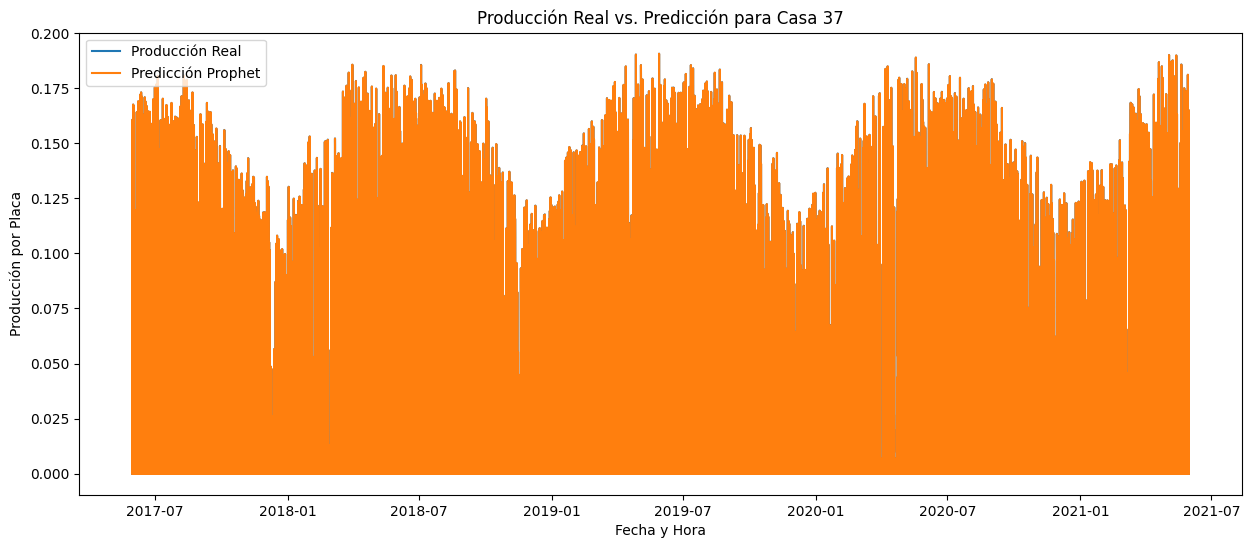

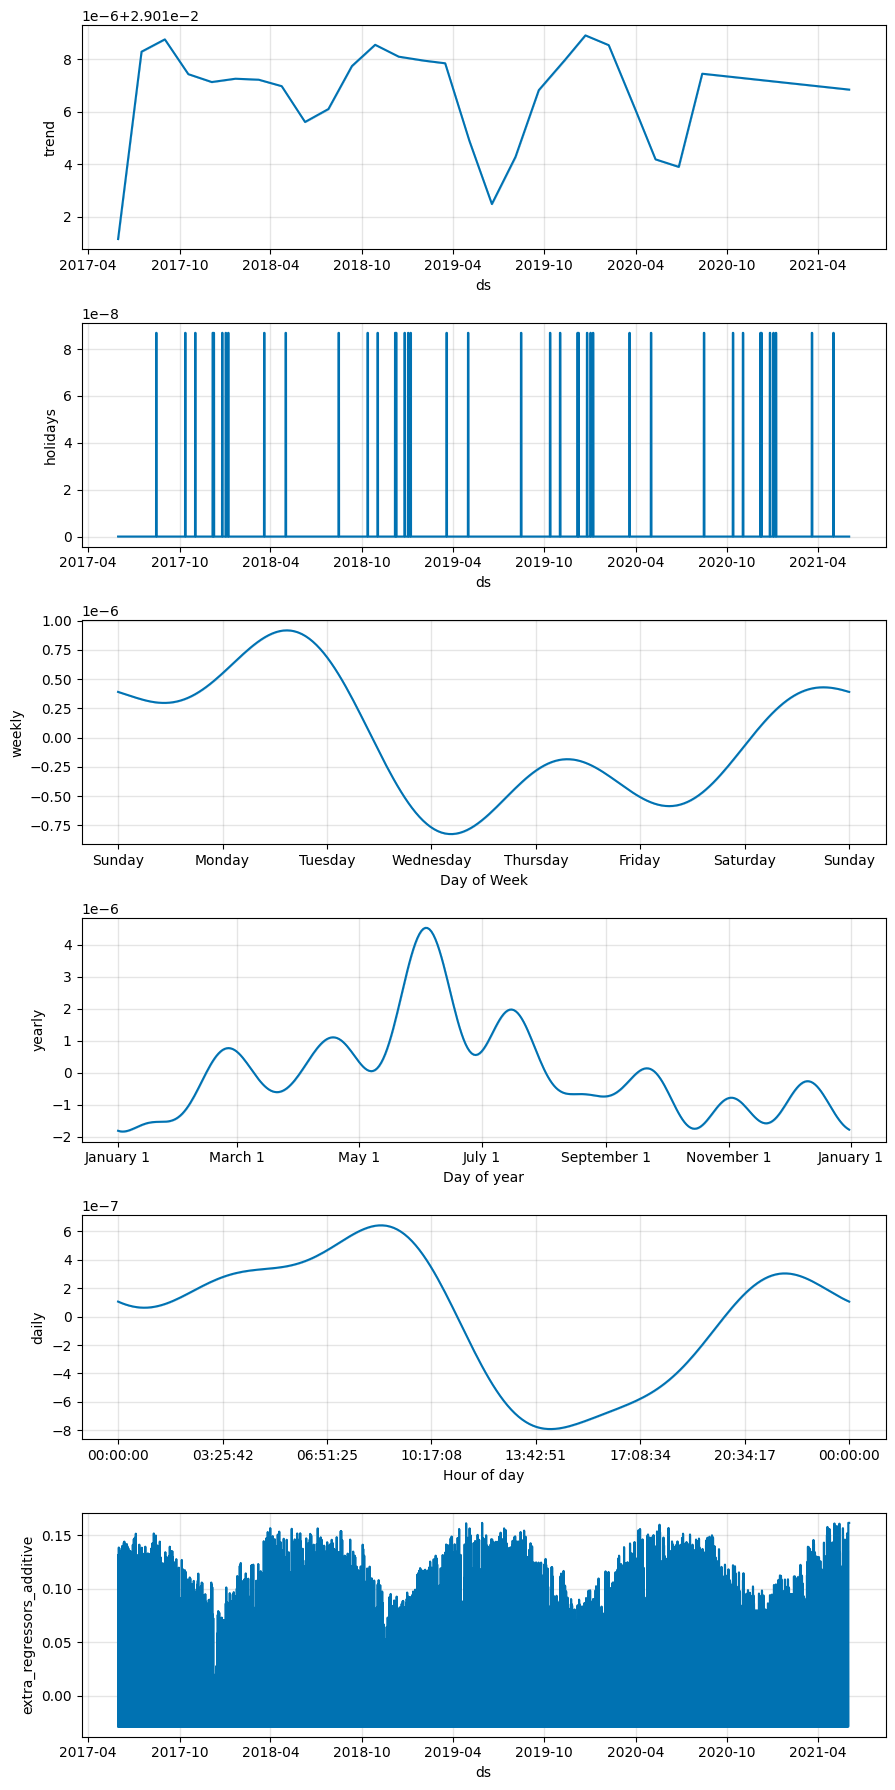

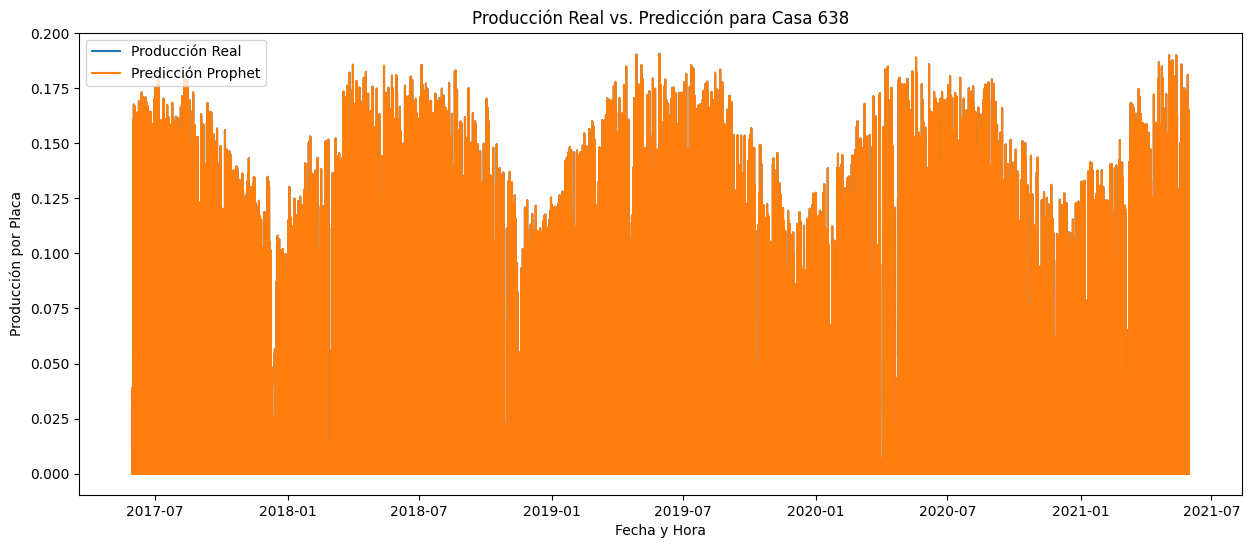

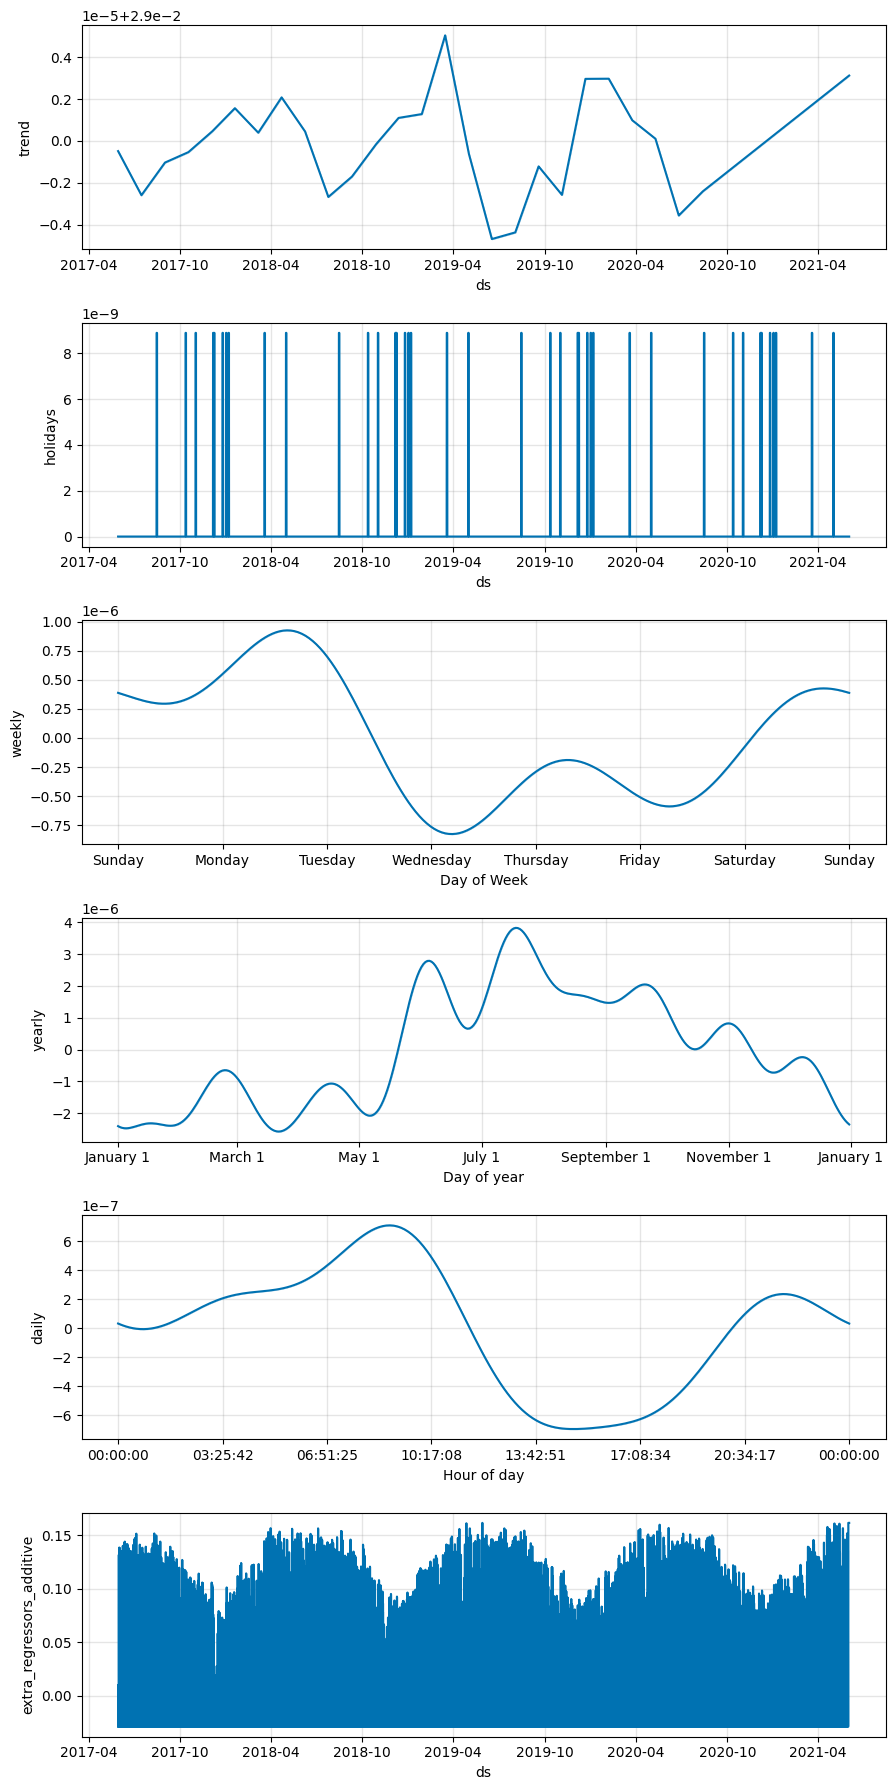

                  mse       mae
id_casa                        
37       1.289905e-09  0.000021
638      1.288724e-09  0.000021


In [6]:
resultados_evaluacion = {}

for i, (casa_id, datos) in enumerate(resultados_por_casa.items()):
    forecast = datos['forecast']
    datos_entrenamiento = datos['datos_entrenamiento']

    # Fusionar datos reales y predicciones para la evaluación
    evaluacion_df = pd.merge(datos_entrenamiento, forecast[['ds', 'yhat']], on='ds')

    # Calcular métricas de error
    mse = mean_squared_error(evaluacion_df['y'], evaluacion_df['yhat'])
    mae = mean_absolute_error(evaluacion_df['y'], evaluacion_df['yhat'])

    resultados_evaluacion[casa_id] = {
        'mse': mse,
        'mae': mae
    }

    # Gráficas para las primeras 10 casas
    if i < 10:
        plt.figure(figsize=(15, 6))
        plt.plot(evaluacion_df['ds'], evaluacion_df['y'], label='Producción Real')
        plt.plot(evaluacion_df['ds'], evaluacion_df['yhat'], label='Predicción Prophet')
        plt.title(f'Producción Real vs. Predicción para Casa {casa_id}')
        plt.xlabel('Fecha y Hora')
        plt.ylabel('Producción por Placa')
        plt.legend()
        plt.show()

        fig_components = datos['modelo'].plot_components(datos['forecast'])
        plt.show()

# Resumen de métricas de error
df_metricas = pd.DataFrame.from_dict(resultados_evaluacion, orient='index')
df_metricas.index.name = 'id_casa'
print(df_metricas)
